# Hierarchical / Multi-Resolution GraphKoopman

This notebook assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here that loop uses
hierarchical pooling for multi-resolution latents.

This notebook uses the **power-user** module `koopman_graph.hierarchical`:

- Pool a fine grid with PyG **TopK** (optional `pooling="sag"`)
- Run a composed `GraphKoopmanModel` on the **coarse** graph
- Scatter-unpool predictions back to fine resolution

### Caveats (read first)

- This is **coarse-level forecasting with learned unpooling**, not
  physics-augmented spatiotemporal **super-resolution**.
- P-K-GCN (Zhang et al., 2026, arXiv:2606.19303) is a related *coarse→fine*
  precedent in a different problem setting — cite carefully; do not equate
  the APIs.
- Forecasting only at the coarsest level can miss fine-scale structure.
  Inspect both `resolution="coarse"` and `resolution="fine"`.
- `pool_ratios=(1.0,)` keeps all nodes (identity reduction) as a sanity check
  against a flat model.
- Classes are **not** on the root `koopman_graph` façade.


## Method: flat vs hierarchical pooling

Compare a flat `GraphKoopmanModel` to a hierarchical variant (TopK ratio 0.5)
on Laplacian diffusion. We report:

- **In-sample**, single-origin (`start_indices=[0]`) multi-step RMSE via
  `evaluate_forecast` — a teaching-scale score, not a holdout benchmark
- Fine-grid spatial snapshots (truth vs flat vs hier-fine) at that origin
- `hier.spectrum(...)` on the composed (dense) operator — the hierarchical
  API always pools the reference graph first; topology changes the spectrum
  only when the inner model uses `koopman="graph"`
- A `pool_ratios=(1.0,)` no-op size check

Wall-clock timings are intentionally omitted: they are not Restart & Run All
stable across machines or even consecutive clean runs.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets import GridDynamicGraphBenchmark
from koopman_graph.hierarchical import HierarchicalGraphKoopmanModel
from koopman_graph.metrics import evaluate_forecast

# Quick-run defaults; increase N / epochs for a fuller demo.
CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
N_ROWS = 8 if CI else 16
N_COLS = 8 if CI else 16
NUM_TIMESTEPS = 40 if CI else 60
EPOCHS = 8 if CI else 40
STEPS = 5 if CI else 10
HIDDEN = 16
LATENT = 8
LR = 5e-3
TIME_STEP = 0.1
MODEL_SEED = 0
NOOP_SEED = 1
POOL_RATIOS = (0.5,)
ORIGIN = 0
IN_CHANNELS = 1
print(f"grid={N_ROWS}x{N_COLS} nodes={N_ROWS * N_COLS} epochs={EPOCHS}")


grid=16x16 nodes=256 epochs=40


## Helper functions

Notebook-local helpers used below.


In [2]:
def make_model(seed: int = MODEL_SEED) -> GraphKoopmanModel:
    torch.manual_seed(seed)
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels=IN_CHANNELS,
            hidden_channels=HIDDEN,
            latent_dim=LATENT,
        ),
        decoder=GNNDecoder(
            latent_dim=LATENT,
            hidden_channels=HIDDEN,
            out_channels=IN_CHANNELS,
        ),
        latent_dim=LATENT,
        time_step=TIME_STEP,
    )


def to_grid(x: torch.Tensor) -> torch.Tensor:
    """Reshape fine node features `(N, F)` to `(N_ROWS, N_COLS)` for imshow."""
    return x[:, 0].detach().cpu().reshape(N_ROWS, N_COLS)


## Generate Laplacian diffusion data on a 2D grid


In [3]:
sequence = GridDynamicGraphBenchmark.generate(
    num_rows=N_ROWS,
    num_cols=N_COLS,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    diffusion_rate=0.08,
    decay_rate=0.99,
    noise_std=0.0,
    seed=0,
)
print(sequence[0])
print(f"num_nodes={sequence.num_nodes}")


Data(x=[256, 1], edge_index=[2, 960])
num_nodes=256


## Train: flat baseline vs hierarchical (TopK ratio 0.5)


In [4]:
flat = make_model(seed=MODEL_SEED)
flat.fit(sequence, epochs=EPOCHS, lr=LR)

hier = HierarchicalGraphKoopmanModel(
    make_model(seed=MODEL_SEED),
    pool_ratios=POOL_RATIOS,
)
hier.fit(
    sequence,
    epochs=EPOCHS,
    lr=LR,
    unpool_epochs=max(3, EPOCHS // 4),
)
print("fit complete: flat + hierarchical (TopK)")


fit complete: flat + hierarchical (TopK)


## Evaluate: in-sample RMSE, spectrum, and fine-grid snapshots

Protocol: same sequence used for `fit`; one forecast origin (`ORIGIN`);
horizon `STEPS`. Hierarchical `evaluate_forecast` uses the default
`predict(..., resolution="fine")` path.

`hier.spectrum(reference_graph)` pools the reference snapshot, then analyzes
the composed operator. With the default dense $K$ used here, eigenvalues
match `hier.model.spectrum()` (topology-independent). For networked
`koopman="graph"` models, the coarse `edge_index` / node count matter.


In [5]:
horizon = STEPS
target_t = ORIGIN + horizon

flat_preds = flat.predict(sequence[ORIGIN], steps=horizon)
hier_fine = hier.predict(sequence[ORIGIN], steps=horizon, resolution="fine")
hier_coarse = hier.predict(sequence[ORIGIN], steps=horizon, resolution="coarse")

flat_eval = evaluate_forecast(
    flat, sequence, horizons=(horizon,), start_indices=[ORIGIN]
)
hier_eval = evaluate_forecast(
    hier, sequence, horizons=(horizon,), start_indices=[ORIGIN]
)

spec = hier.spectrum(sequence[ORIGIN])
mags = spec.magnitudes.detach().cpu()

print(
    f"protocol: in-sample, origin={ORIGIN}, horizon={horizon}, "
    f"num_origins={flat_eval.num_origins}"
)
print(f"flat RMSE:  {flat_eval.aggregate_rmse:.4f}")
print(f"hier RMSE:  {hier_eval.aggregate_rmse:.4f}")
print(
    f"coarse nodes: {hier_coarse[0].x.shape[0]}  "
    f"fine nodes: {hier_fine[0].x.shape[0]}"
)
print(f"hier.spectrum magnitudes (dense K; pooled API path): {mags.tolist()}")
print(
    "note: |lambda| > 1 modes are unregularized dense-K eigenvalues, "
    "not a stability claim for this demo"
)


protocol: in-sample, origin=0, horizon=10, num_origins=1
flat RMSE:  0.8433
hier RMSE:  0.6108
coarse nodes: 128  fine nodes: 256
hier.spectrum magnitudes (dense K; pooled API path): [1.0311602354049683, 1.0311602354049683, 1.0225191116333008, 0.9988768696784973, 0.9988768696784973, 0.9793077707290649, 0.9793077707290649, 0.9779573678970337]
note: |lambda| > 1 modes are unregularized dense-K eigenvalues, not a stability claim for this demo


## Results: RMSE summary and spatial multi-resolution view

Aggregate in-sample RMSE can favor hierarchical even when the unpooled fine
field looks blocky: TopK keeps a subset of nodes, and scatter-unpool + refine
does not reconstruct a smooth grid. Read the spatial panels together with the
caveats (coarse forecasting ≠ super-resolution).

The stem plot is an API demo of `hier.spectrum` on this dense-$K$ model —
not a claim that TopK changed the eigenvalues. Magnitudes above 1 are
unregularized dense-$K$ modes, not a stability guarantee.


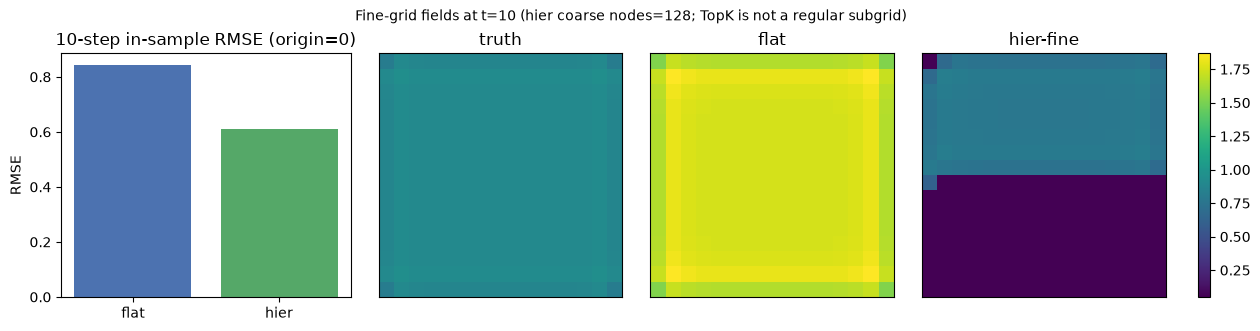

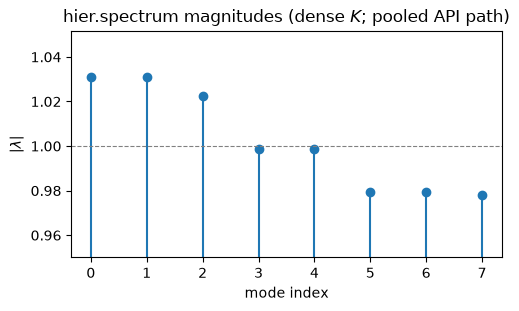

In [6]:
truth = to_grid(sequence[target_t].x)
flat_field = to_grid(flat_preds[horizon - 1].x)
hier_field = to_grid(hier_fine[horizon - 1].x)
vmin = float(min(truth.min(), flat_field.min(), hier_field.min()))
vmax = float(max(truth.max(), flat_field.max(), hier_field.max()))

fig, axes = plt.subplots(
    1,
    4,
    figsize=(12.5, 3.2),
    gridspec_kw={"width_ratios": [1.1, 1, 1, 1]},
    constrained_layout=True,
)
axes[0].bar(
    ["flat", "hier"],
    [flat_eval.aggregate_rmse, hier_eval.aggregate_rmse],
    color=["#4C72B0", "#55A868"],
)
axes[0].set_ylabel("RMSE")
axes[0].set_title(f"{horizon}-step in-sample RMSE (origin={ORIGIN})")

ims = []
for axis, field, title in zip(
    axes[1:],
    [truth, flat_field, hier_field],
    ["truth", "flat", "hier-fine"],
    strict=True,
):
    im = axis.imshow(field, origin="upper", vmin=vmin, vmax=vmax, cmap="viridis")
    ims.append(im)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
fig.colorbar(ims[-1], ax=axes[1:], fraction=0.046, pad=0.04)
fig.suptitle(
    f"Fine-grid fields at t={target_t} "
    f"(hier coarse nodes={hier_coarse[0].x.shape[0]}; TopK is not a regular subgrid)",
    fontsize=10,
)
plt.show()

fig2, ax2 = plt.subplots(figsize=(5, 3), constrained_layout=True)
ax2.stem(range(len(mags)), mags.numpy(), basefmt=" ")
ax2.set_xlabel("mode index")
ax2.set_ylabel(r"$|\lambda|$")
ax2.set_title("hier.spectrum magnitudes (dense $K$; pooled API path)")
ylo = float(min(0.95, 0.98 * mags.min()))
yhi = float(max(1.05, 1.02 * mags.max()))
ax2.set_ylim(ylo, yhi)
ax2.axhline(1.0, color="0.5", ls="--", lw=0.8)
plt.show()


## Results: no-op sanity (`pool_ratios=(1.0,)`)


In [7]:
noop = HierarchicalGraphKoopmanModel(
    make_model(seed=NOOP_SEED),
    pool_ratios=(1.0,),
)
noop.fit(
    sequence,
    epochs=max(3, EPOCHS // 2),
    lr=LR,
    unpool_epochs=2,
)
coarse0, _steps = noop.pool_down(sequence[0])
assert coarse0.x.shape[0] == sequence.num_nodes
print("noop coarse nodes:", coarse0.x.shape[0], "== fine", sequence.num_nodes)

# Optional SAGPooling path (constructor only; not trained in this notebook).
sag = HierarchicalGraphKoopmanModel(
    make_model(seed=NOOP_SEED),
    pool_ratios=POOL_RATIOS,
    pooling="sag",
)
print("pooling='sag' layer type:", type(sag.pool_layers[0]).__name__)


noop coarse nodes: 256 == fine 256
pooling='sag' layer type: SAGPooling


## Takeaways

1. Import hierarchical APIs from `koopman_graph.hierarchical` (power-user).
2. Default pooling is TopK; pass `pooling="sag"` for SAGPooling (same constructor;
   see the one-liner after the no-op check). Related helpers: `build_pool_layer`,
   `ScatterUnpool`, `PoolStep`.
3. Use `predict(..., resolution="coarse"|"fine")` for multi-resolution outputs.
   `hier.spectrum(reference_graph)` always pools first; the coarse topology
   changes eigenvalues only for `koopman="graph"` (this notebook uses dense
   $K$, so the stem plot is an API demo).
4. On this teaching-scale Laplacian demo, hierarchical fine RMSE can beat a
   small flat baseline under the labeled in-sample protocol — that is not a
   general Pareto claim.
5. Inspect spatial fields: lower aggregate RMSE can still look blocky after
   TopK + scatter-unpool (see the hier-fine panel).
6. Do not market this wrapper as P-K-GCN super-resolution.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the flat base workflow.
- See [`14_physics_informed_advection.ipynb`](14_physics_informed_advection.ipynb) for physics lifting on grids.
- See [`04_grid_attention.ipynb`](04_grid_attention.ipynb) for GAT on directional grids.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) for spectrum interpretation.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
